# Introduction
Les activités malveillantes sur Internet, également appelées intrusions, constituent une menace majeure pour la sécurité des systèmes informatiques et des réseaux. Une intrusion est définie comme toute activité violant la politique de sécurité d’un réseau. Les systèmes de détection d'intrusion (IDS - Intrusion Detection Systems) jouent un rôle crucial en identifiant les utilisations non autorisées ou les attaques ciblant les ordinateurs et les réseaux. Ces systèmes, complémentaires aux pare-feux et aux logiciels antivirus, assurent la surveillance et l’analyse des activités réseau, détectent les vulnérabilités et fournissent des audits en temps réel des systèmes critiques.

Le Data Mining, en tant qu’outil avancé d’analyse de données, a révolutionné la détection d'intrusions en permettant de traiter de grandes quantités de données réseau. Il utilise des techniques comme la classification, le clustering, les algorithmes d’association, l’analyse séquentielle et la détection d’anomalies pour extraire des modèles et identifier les comportements suspects. En combinant ces méthodes avec les IDS, les organisations peuvent non seulement détecter rapidement les attaques, mais également anticiper les menaces émergentes.

# Principales méthodes de Data Mining pour la détection d'intrusions


## 1. Algorithmes de classification
Ces méthodes catégorisent les données en classes prédéfinies, telles que "normal" ou "anormal".

Exemples d’algorithmes :

Decision Tree Classifier : Basé sur des règles hiérarchiques simples, il est facile à interpréter.
k-Nearest Neighbors (kNN) : Identifie une classe en fonction des voisins les plus proches.
Support Vector Machines (SVM) : Sépare les classes à l’aide d’un hyperplan optimal.
Réseaux neuronaux artificiels (ANN).
Avantages : Appropriés pour des datasets bien étiquetés, offrent des performances élevées pour des intrusions connues.

Limites : Peuvent être sensibles aux changements de données et nécessitent des données équilibrées.



# 2. Techniques de clustering
Le clustering regroupe les données en fonction de leur similarité sans utiliser de labels.

Exemples d’algorithmes :

k-means : Divise les données en un nombre fixe de clusters.
DBSCAN : Identifie des clusters de densité et des points isolés (anomalies).
Clustering hiérarchique.
Avantages : Utile pour identifier des schémas émergents ou inconnus, flexible aux changements.

Limites : Dépend du choix des paramètres et des mesures de similarité.




## 3. Algorithmes d’association
Ces algorithmes découvrent des relations fréquentes ou des règles d'association entre différentes activités réseau.

Exemple d’algorithme : Apriori.

Avantages : Identifie des schémas d'activités corrélées, potentiellement indicatifs de comportements malveillants.

Limites : Génère de nombreuses règles, nécessitant une analyse approfondie pour extraire celles qui sont pertinentes.


## 4. Analyse de séquence
Cette méthode détecte des modèles d'activités temporelles ou des séquences anormales d'événements dans le trafic réseau.

Applications : Détection d’attaques complexes se déroulant en plusieurs étapes.

Avantages : Utile pour les attaques progressives (par exemple, slow DoS attacks).

Limites : Nécessite une gestion sophistiquée des données temporelles.


## 5. Méthodes basées sur les signatures
Ces méthodes comparent les modèles observés avec une base de signatures préenregistrées (attaques connues).

Avantages : Très précises pour détecter des intrusions connues.

Limites : Inefficaces contre les nouvelles menaces ou les attaques polymorphes.


## 6. Méthodes basées sur l’anomalie
Ces méthodes construisent un modèle de comportement "normal" et détectent les écarts significatifs.

Exemples d’algorithmes :

Isolation Forest : Identifie les anomalies en isolant les points atypiques.
Autoencoders : Reconstruisent les données normales, avec des erreurs élevées signalant des anomalies.
One-Class SVM.

Avantages : Détectent des attaques inconnues et s’adaptent à l’évolution des menaces.

Limites : Génèrent souvent des faux positifs, nécessitant un réglage précis.

# Conclusion
Le choix de la méthode de détection dépend fortement de la nature des données et des objectifs du projet. Une combinaison de plusieurs méthodes est souvent recommandée pour bénéficier de leurs avantages respectifs. Dans le cadre de ce projet, des algorithmes supervisés comme kNN, régression logistique, et Decision Tree seront utilisés pour la classification, tandis que Random Forest sera employé pour identifier les variables significatives. Cette approche comparative permettra d’évaluer les performances des différentes méthodes et de choisir la solution la plus adaptée pour la détection d'intrusions dans un réseau informatique.

# Code Source

### Importation des bibliothèques

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
import warnings
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree  import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import BernoulliNB
from lightgbm import LGBMClassifier
from sklearn.feature_selection import RFE
import itertools
from xgboost import XGBClassifier
from tabulate import tabulate

In [10]:
train=pd.read_csv('kdd_train.csv')
test = pd.read_csv('kdd_test.csv')

In [11]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [13]:
train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
train.describe(include='object')

,protocol_type,service,flag,labels
count,125973,125973,125973,125973
unique,3,70,11,23
top,tcp,http,SF,normal
freq,102689,40338,74945,67343


In [15]:
train.shape

(125973, 42)

# Préparation des données 

In [16]:
train.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [17]:
total = train.shape[0]
missing_columns = [col for col in train.columns if train[col].isnull().sum() > 0]
for col in missing_columns:
    null_count = train[col].isnull().sum()
    per = (null_count/total) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")

In [18]:
print(f"Number of duplicate rows: {train.duplicated().sum()}")

Number of duplicate rows: 0


In [21]:
print('Class distribution Training set:')
print(train['labels'].value_counts())

Class distribution Training set:
labels
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [23]:
def le(df):
    for col in df.columns:
        if df[col].dtype == 'object':
                label_encoder = LabelEncoder()
                df[col] = label_encoder.fit_transform(df[col])

le(train)
le(test)

In [24]:
train.drop(['num_outbound_cmds'], axis=1, inplace=True)
test.drop(['num_outbound_cmds'], axis=1, inplace=True)

In [25]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,11
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,11
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,9
3,0,1,24,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,11
4,0,1,24,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11


In [26]:
X_train = train.drop(['labels'], axis=1)
Y_train = train['labels']

#### Visualisation du data set

###### Répartition des Labels (normal vs anomalie)

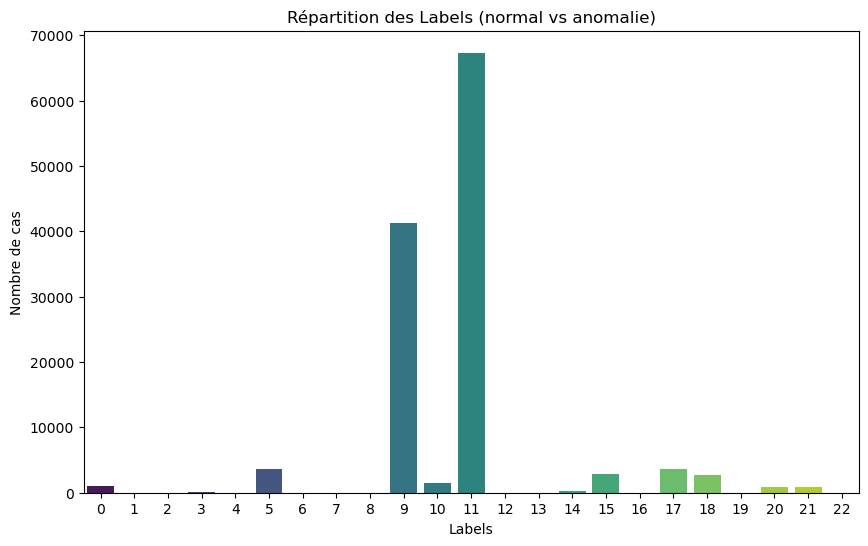

In [71]:

plt.figure(figsize=(10, 6))
sns.countplot(x='labels', data=train, palette='viridis')
plt.title('Répartition des Labels (normal vs anomalie)')
plt.xlabel('Labels')
plt.ylabel('Nombre de cas')
plt.show()


###### Répartition des Types de Protocoles

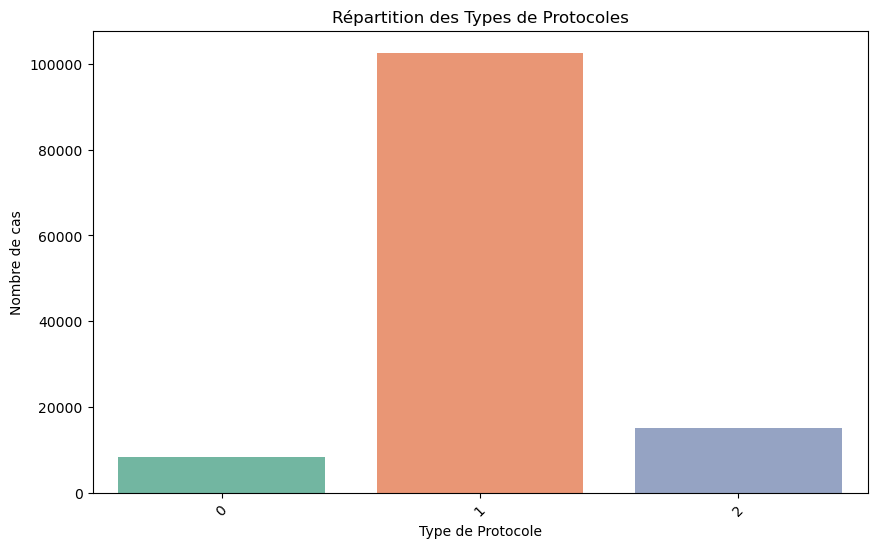

In [72]:

plt.figure(figsize=(10, 6))
sns.countplot(x='protocol_type', data=train, palette='Set2')
plt.title('Répartition des Types de Protocoles')
plt.xlabel('Type de Protocole')
plt.ylabel('Nombre de cas')
plt.xticks(rotation=45)  
plt.show()


##### Répartition des Services

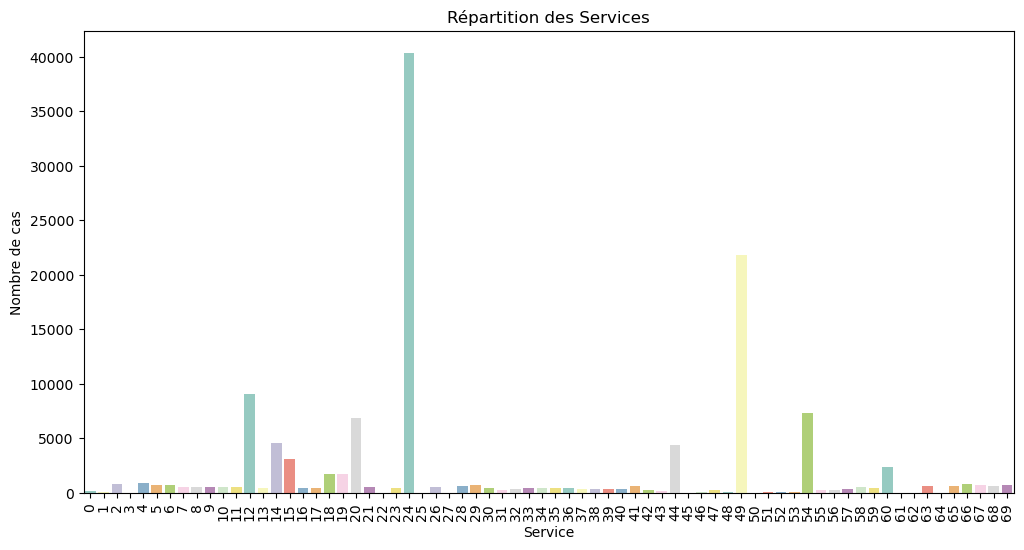

In [74]:
plt.figure(figsize=(12, 6))
sns.countplot(x='service', data=train, palette='Set3')
plt.title('Répartition des Services')
plt.xlabel('Service')
plt.ylabel('Nombre de cas')
plt.xticks(rotation=90)  
plt.show()


In [27]:
rfc = RandomForestClassifier()

rfe = RFE(rfc, n_features_to_select=10)
rfe = rfe.fit(X_train, Y_train)

feature_map = [(i, v) for i, v in itertools.zip_longest(rfe.get_support(), X_train.columns)]
selected_features = [v for i, v in feature_map if i==True]

selected_features

['flag',
 'src_bytes',
 'dst_bytes',
 'count',
 'same_srv_rate',
 'diff_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate']

In [28]:
X_train = X_train[selected_features]
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
test = scale.fit_transform(test)

In [29]:
x_train, x_test, y_train, y_test = train_test_split(X_train, Y_train, train_size=0.70, random_state=2)

In [30]:
print("x_train shape:",x_train.shape)
print("x_test.shape:",x_test.shape)
print("y_train.shape:",y_train.shape)
print("y_test.shape:",y_test.shape)


x_train shape: (88181, 10)
x_test.shape: (37792, 10)
y_train.shape: (88181,)
y_test.shape: (37792,)


## Application de Logistic Regression Algorithme

In [31]:
import time
from sklearn.linear_model import LogisticRegression
  
clfl = LogisticRegression(max_iter = 1200000)
start_time = time.time()
clfl.fit(x_train, y_train.values.ravel())
end_time = time.time()
print("Training time: ", end_time-start_time)

Training time:  66.2310585975647


In [32]:
start_time = time.time()
y_test_pred = clfl.predict(x_train)
end_time = time.time()
print("Testing time: ", end_time-start_time)

Testing time:  0.04297375679016113


In [33]:
lg_model = LogisticRegression(random_state = 42)
lg_model.fit(x_train, y_train)

C:\Users\brahm\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

### Évaluation du model

In [34]:
lg_train, lg_test = lg_model.score(x_train , y_train), lg_model.score(x_test , y_test)

print(f"Training Score: {lg_train}")
print(f"Test Score: {lg_test}")

Training Score: 0.9263333371134371
Test Score: 0.9253281117696867


In [41]:
pip install optuna

  Obtaining dependency information for optuna from https://files.pythonhosted.org/packages/e8/30/35111dae435c640694d616a611b7ff6b2482cfd977f8f572ff960a321d66/optuna-4.1.0-py3-none-any.whl.metadata
  Obtaining dependency information for alembic>=1.5.0 from https://files.pythonhosted.org/packages/cb/06/8b505aea3d77021b18dcbd8133aa1418f1a1e37e432a465b14c46b2c0eaa/alembic-1.14.0-py3-none-any.whl.metadata
  Obtaining dependency information for colorlog from https://files.pythonhosted.org/packages/e3/51/9b208e85196941db2f0654ad0357ca6388ab3ed67efdbfc799f35d1f83aa/colorlog-6.9.0-py3-none-any.whl.metadata
  Obtaining dependency information for Mako from https://files.pythonhosted.org/packages/1e/bf/7a6a36ce2e4cafdfb202752be68850e22607fccd692847c45c1ae3c17ba6/Mako-1.3.8-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/364.4 kB ? eta -:--:--
   --- ----------------------------------- 30.7/364.4 kB 660.6 kB/s eta 0:00:01
   ------- ------------------------------- 71.7/364

## Application de KNN algorithm

In [42]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [43]:
def objective(trial):
    n_neighbors = trial.suggest_int('KNN_n_neighbors', 2, 16, log=False)
    classifier_obj = KNeighborsClassifier(n_neighbors=n_neighbors)
    classifier_obj.fit(x_train, y_train)
    accuracy = classifier_obj.score(x_test, y_test)
    return accuracy

In [44]:
study_KNN = optuna.create_study(direction='maximize')
study_KNN.optimize(objective, n_trials=1)
print(study_KNN.best_trial)

FrozenTrial(number=0, state=1, values=[0.9754445385266723], datetime_start=datetime.datetime(2024, 12, 9, 21, 54, 5, 793025), datetime_complete=datetime.datetime(2024, 12, 9, 21, 54, 17, 232072), params={'KNN_n_neighbors': 9}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'KNN_n_neighbors': IntDistribution(high=16, log=False, low=2, step=1)}, trial_id=0, value=None)


### Évaluation du model

In [45]:
KNN_model = KNeighborsClassifier(n_neighbors=study_KNN.best_trial.params['KNN_n_neighbors'])
KNN_model.fit(x_train, y_train)

KNN_train, KNN_test = KNN_model.score(x_train, y_train), KNN_model.score(x_test, y_test)

print(f"Train Score: {KNN_train}")
print(f"Test Score: {KNN_test}")

Train Score: 0.9787255758043116
Test Score: 0.9754445385266723


## Application de Decision Tree Classifier

In [46]:
from sklearn.tree import DecisionTreeClassifier
  
clfd = DecisionTreeClassifier(criterion ="entropy", max_depth = 4)
start_time = time.time()
clfd.fit(x_train, y_train.values.ravel())
end_time = time.time()
print("Training time: ", end_time-start_time)

Training time:  0.22386860847473145


In [47]:
start_time = time.time()
y_test_pred = clfd.predict(x_train)
end_time = time.time()
print("Testing time: ", end_time-start_time)

Testing time:  0.026983022689819336


In [48]:
def objective(trial):
    dt_max_depth = trial.suggest_int('dt_max_depth', 2, 32, log=False)
    dt_max_features = trial.suggest_int('dt_max_features', 2, 10, log=False)
    classifier_obj = DecisionTreeClassifier(max_features = dt_max_features, max_depth = dt_max_depth)
    classifier_obj.fit(x_train, y_train)
    accuracy = classifier_obj.score(x_test, y_test)
    return accuracy

In [49]:
study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective, n_trials=30)
print(study_dt.best_trial)

FrozenTrial(number=7, state=1, values=[0.9964542760372566], datetime_start=datetime.datetime(2024, 12, 9, 21, 55, 58, 522590), datetime_complete=datetime.datetime(2024, 12, 9, 21, 55, 58, 853419), params={'dt_max_depth': 16, 'dt_max_features': 5}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'dt_max_depth': IntDistribution(high=32, log=False, low=2, step=1), 'dt_max_features': IntDistribution(high=10, log=False, low=2, step=1)}, trial_id=7, value=None)


### Evaluation du model

In [50]:
dt = DecisionTreeClassifier(max_features = study_dt.best_trial.params['dt_max_features'], max_depth = study_dt.best_trial.params['dt_max_depth'])
dt.fit(x_train, y_train)

dt_train, dt_test = dt.score(x_train, y_train), dt.score(x_test, y_test)

print(f"Train Score: {dt_train}")
print(f"Test Score: {dt_test}")

Train Score: 0.9987752463682653
Test Score: 0.9949724809483489


## Comparaison entre les différents modèles 

In [51]:
data = [["KNN", KNN_train, KNN_test], 
        ["Logistic Regression", lg_train, lg_test],
        ["Decision Tree", dt_train, dt_test]]

col_names = ["Model", "Train Score", "Test Score"]
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

╒═════════════════════╤═══════════════╤══════════════╕
│ Model               │   Train Score │   Test Score │
╞═════════════════════╪═══════════════╪══════════════╡
│ KNN                 │      0.978726 │     0.975445 │
├─────────────────────┼───────────────┼──────────────┤
│ Logistic Regression │      0.926333 │     0.925328 │
├─────────────────────┼───────────────┼──────────────┤
│ Decision Tree       │      0.998775 │     0.994972 │
╘═════════════════════╧═══════════════╧══════════════╛


In [52]:
SEED = 42

### Decision Tree Model

In [53]:
dtc = DecisionTreeClassifier()

### KNN

In [54]:
knn = KNeighborsClassifier()

### LOGISTIC REGRESSION MODEL

In [55]:
lr = LogisticRegression()

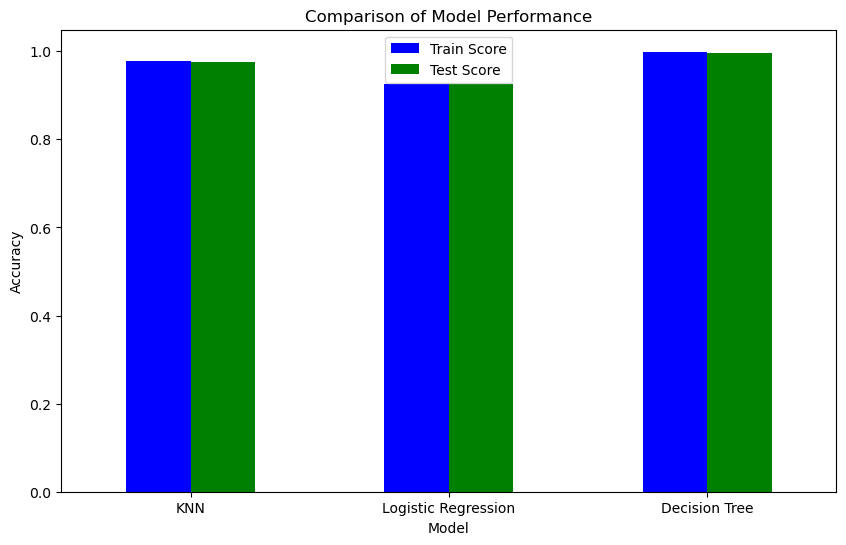

In [69]:
# Créez un graphique pour comparer les scores d'entraînement et de test
scores = pd.DataFrame({
    'Model': ['KNN', 'Logistic Regression', 'Decision Tree'],
    'Train Score': [KNN_train, lg_train, dt_train],
    'Test Score': [KNN_test, lg_test, dt_test]
})

scores.plot(kind='bar', x='Model', y=['Train Score', 'Test Score'], figsize=(10, 6), rot=0, color=['blue', 'green'])
plt.title('Comparison of Model Performance')
plt.ylabel('Accuracy')
plt.show()




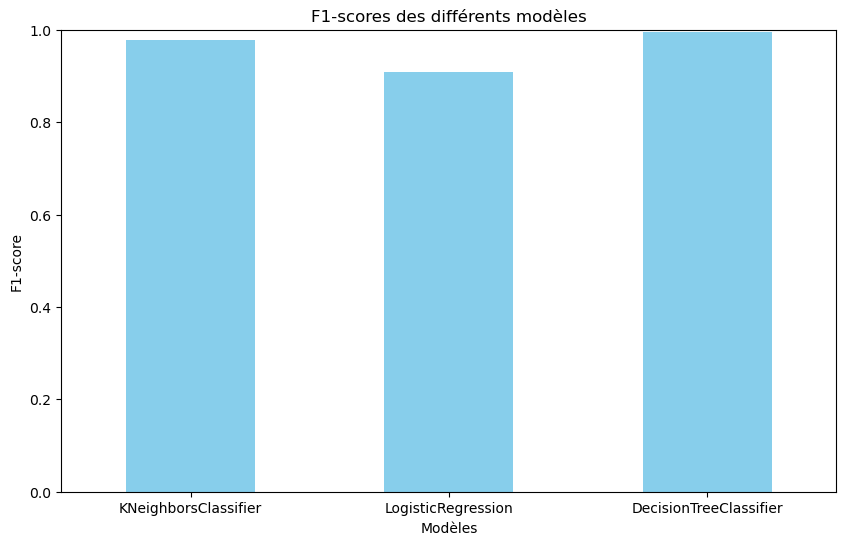

In [76]:
# Dictionnaire pour stocker les F1-scores des différents modèles
f1_scores = {}

# Calcul du F1-score pour chaque modèle
for name in models:
    f1_scores[name] = f1_score(y_test, preds[name], average='weighted')  # weighted pour prendre en compte l'équilibre des classes

# Convertir le dictionnaire en DataFrame pour une représentation plus facile
f1_scores_df = pd.DataFrame(f1_scores.values(), index=f1_scores.keys(), columns=["F1-score"])

# Affichage des résultats sous forme de graphique
f1_scores_df.plot(kind="bar", ylim=[0, 1], figsize=(10, 6), color='skyblue', legend=False)
plt.title("F1-scores des différents modèles")
plt.ylabel("F1-score")
plt.xlabel("Modèles")
plt.xticks(rotation=0)
plt.show()


# Discuter des résultats obtenus et en tirer des conclusions

Les résultats des modèles testés sur le dataset NSL-KDD pour la détection d'intrusions montrent des différences intéressantes en termes de performances, ce qui permet d'envisager des recommandations sur l'utilisation des différentes techniques de classification dans ce contexte.

KNeighborsClassifier (KNN) et DecisionTreeClassifier (Arbre de décision) : Ces deux modèles ont obtenu des scores F1 très similaires, proches de 1, ce qui indique une excellente capacité à détecter les intrusions, avec un bon équilibre entre précision et rappel. Ces résultats suggèrent que ces deux algorithmes sont particulièrement adaptés pour ce type de tâche. KNN, avec sa méthode de proximité, semble bien s'adapter aux caractéristiques du dataset, en réussissant à capter les patterns d'intrusions de manière précise. De son côté, l'arbre de décision offre une interprétation claire des décisions grâce à sa structure arborescente, ce qui peut être un avantage supplémentaire dans des applications où la transparence est nécessaire.

LogisticRegression (Régression logistique) : Bien que la régression logistique ait également donné un score F1 relativement élevé, ce score est inférieur à celui des autres modèles. La régression logistique pourrait souffrir de la manière dont elle modélise les données, en particulier dans un problème complexe comme la détection d'intrusions, où les relations entre les variables ne sont pas nécessairement linéaires. Cela explique pourquoi elle a obtenu des résultats légèrement moins bons que KNN et l'arbre de décision.

# Conclusion

Sur la base des résultats obtenus, KNeighborsClassifier et DecisionTreeClassifier apparaissent comme les modèles les plus performants pour la détection d'intrusions dans le dataset NSL-KDD. Ces deux modèles montrent une capacité robuste à identifier les intrusions, avec des scores F1 proches de la perfection, indiquant un équilibre efficace entre la détection des attaques (rappel) et la minimisation des faux positifs (précision). En revanche, LogisticRegression, bien qu’efficace, n’a pas atteint la même performance, probablement en raison de la nature linéaire de ce modèle, qui pourrait ne pas capturer les complexités des données de manière optimale.

Il serait pertinent d’explorer ces modèles plus en profondeur, notamment en optimisant leurs hyperparamètres et en appliquant des techniques de validation croisée pour confirmer la stabilité de leurs performances à travers différents jeux de données. L’analyse des courbes ROC pourrait également fournir des informations supplémentaires sur le compromis entre le taux de faux positifs et vrais positifs pour ces modèles.

Bien que les résultats soient prometteurs, il est essentiel de noter que la performance des modèles peut varier en fonction des ensembles de données. Ainsi, des tests supplémentaires sur d’autres jeux de données ou dans des conditions variées pourraient donner un aperçu plus complet de leur robustesse. Par ailleurs, d'autres techniques avancées, comme le clustering ou les réseaux neuronaux, pourraient offrir des performances encore améliorées, bien qu'elles nécessitent des ajustements plus fins et une validation plus rigoureuse.

en discutant des résultats obtenus et en tirant des conclusions, nous serons en mesure de déterminer les méthodes les plus efficaces pour la détection d'intrusion IDS dans un réseau informatique, ainsi que d'identifier les facteurs à prendre en compte lors du choix d'une méthode. Chaque méthode de Data Mining présente des avantages et des inconvénients, et il est important de les évaluer en fonction des besoins spécifiques d'une organisation ou d'un réseau informatique. Le choix de la méthode appropriée peut contribuer de manière significative à la sécurité et à la protection des données dans un environnement informatique.